<a href="https://colab.research.google.com/github/itsnik101/icu-mortality-prediction/blob/main/Meidcal_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

Not to touch Again.....

In [ ]:
# 1. Download the zipped dataset and the outcomes (labels)
!wget https://physionet.org/static/published-projects/challenge-2012/1.0.0/set-a.zip
!wget https://physionet.org/static/published-projects/challenge-2012/1.0.0/Outcomes-a.txt

# 2. Unzip the patient files into a folder named 'set-a'
!unzip -q set-a.zip -d ./data

# 3. Verify the download
import os
files = os.listdir('./data/set-a')
print(f"Successfully downloaded {len(files)} patient files.")

In [ ]:
import pandas as pd
from pathlib import Path # Fixed: Changed from 'import pathlib as path'
from tqdm import tqdm

DATA_DIR = Path("./data/set-a") # Fixed: Removed extra double quote
all_files = list(DATA_DIR.glob("*.txt"))

final_rows = []

for f in tqdm(all_files):
    df = pd.read_csv(f)
    patient_data = {'RecordId': int(f.stem)}
    res = df.groupby('Parameter')['Value'].mean() # Corrected: 'value' to 'Value'

    patient_data.update(res.to_dict()) # Fixed: Typo 'patient_date' to 'patient_data'
    final_rows.append(patient_data)

master_df = pd.DataFrame(final_rows) # Fixed: Typo 'dataframe' to 'DataFrame'

# Fixed: Path construction for to_csv using pathlib
output_dir = Path("/content/drive/MyDrive/Colab Notebooks/AI_Project")
output_dir.mkdir(parents=True, exist_ok=True) # Ensure the directory exists
master_df.to_csv(output_dir / "processed_vitals.csv", index=False)

print("successful")

0it [00:00, ?it/s]

successful


In [ ]:
# Assuming 'all_files' is the list we created earlier
sample_file = all_files[0]

print(f"--- Inspecting File: {sample_file.name} ---")
with open(sample_file, 'r') as f:
    # Print the first 10 lines to see the structure
    for i in range(10):
        print(f.readline().strip())

--- Inspecting File: 140662.txt ---
Time,Parameter,Value
00:00,RecordID,140662
00:00,Age,42
00:00,Gender,1
00:00,Height,-1
00:00,ICUType,3
00:00,Weight,138.1
02:24,FiO2,1
02:24,GCS,15
02:24,HR,125


In [ ]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd

DATA_DIR = Path("./data/set-a") # Corrected path to the unzipped patient files
all_files = list(DATA_DIR.glob("*.txt"))

trend_rows = []

for f in tqdm(all_files):
    df_patient = pd.read_csv(f) # Read each patient's data into a new DataFrame

    # Calculate minutes and max_time for *each patient's df_patient*
    df_patient['minutes'] = df_patient['Time'].apply(lambda x:int(x.split(':')[0])*60+int(x.split(':')[1]))
    max_time = df_patient['minutes'].max()

    first_6h = df_patient[df_patient['minutes'] <= 360]
    last_6h = df_patient[df_patient['minutes'] >= (max_time - 360)]

    patient_trend = {'RecordId': int(f.stem)}
    res_start = first_6h.groupby('Parameter')['Value'].mean()
    res_end = last_6h.groupby('Parameter')['Value'].mean()
    impact_parameters = [
    # --- Vitals (The Hemodynamic Core) ---
    'HR', 'SysABP', 'MAP', 'DiasABP', 'Temp', 'RespRate',

    # --- Neurology (The Consciousness Marker) ---
    'GCS',

    # --- Renal & Fluids (The Kidney/Hydration Filter) ---
    'Urine', 'BUN', 'Creatinine',

    # --- Metabolic & Sepsis (The "Sick" Signal) ---
    'Lactate', 'Glucose', 'WBC', 'pH',

    # --- Respiratory (The Lung Capacity) ---
    'FiO2', 'PaO2', 'PaCO2'
]

    for para in impact_parameters:
         if para in res_start.index and para in res_end.index:
              patient_trend[f'{para}_delta'] = res_end[para] - res_start[para]

         else:
              patient_trend[f'{para}_delta'] = 0

    trend_rows.append(patient_trend)

trend_df = pd.DataFrame(trend_rows)

100%|██████████| 4000/4000 [00:18<00:00, 221.21it/s]


In [ ]:
# Fixed: Path construction for to_csv using pathlib
output_dir = Path("/content/drive/MyDrive/Colab Notebooks/AI_Project")
output_dir.mkdir(parents=True, exist_ok=True) # Ensure the directory exists
trend_df.to_csv(output_dir / "delta_trends.csv", index=False)

print("successful")

successful


In [ ]:
master_df=df

In [ ]:
outcomes=pd.read_csv("/content/Outcomes-a.txt")

In [ ]:
import pandas as pd

# 1. Load the labels
outcomes = pd.read_csv("/content/Outcomes-a.txt")
outcomes=outcomes.rename(columns={'RecordID':'RecordId'})
# 2. Merge them based on the ID column
# Note: Ensure the column names match exactly (RecordID vs RecordId)
final_dataset = pd.merge(master_df, outcomes[['RecordId', 'In-hospital_death']],
                         on='RecordId')

# 3. Drop the redundant column and see your final shape
# The 'RecordID' column was not found after the merge, causing a KeyError.
# It appears that 'RecordId' is already the sole identifier column in final_dataset.
# Therefore, the drop operation for 'RecordID' is unnecessary.
# final_dataset = final_dataset.drop(columns=['RecordID']) # Removed this line
print(f"Final Data Shape: {final_dataset.shape}")

Final Data Shape: (4000, 44)


In [ ]:
#the final input output combined data ....

df=final_dataset

In [ ]:
# Fixed: Path construction for to_csv using pathlib
output_dir = Path("/content/drive/MyDrive/Colab Notebooks/AI_Project")
output_dir.mkdir(parents=True, exist_ok=True) # Ensure the directory exists
df.to_csv(output_dir / "processed_vitals_final.csv", index=False)

print("successful")

successful


Start from here every time for further processing...

In [ ]:
from google.colab import drive
# Adding force_remount=True clears any existing connection and restarts it
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
delta_x=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_Project/delta_trends.csv")

In [ ]:
delta_x.sample(5)

,RecordId,HR_delta,SysABP_delta,MAP_delta,DiasABP_delta,Temp_delta,RespRate_delta,GCS_delta,Urine_delta,BUN_delta,Creatinine_delta,Lactate_delta,Glucose_delta,WBC_delta,pH_delta,FiO2_delta,PaO2_delta,PaCO2_delta
1283,135944,0.571429,0.000000,0.000000,0.000000,-0.300000,0.000000,5.5,-119.642857,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.0,0.0
2624,138005,7.583333,-56.361111,-26.194444,-11.166667,0.792857,0.000000,12.0,-198.285714,6.0,0.3,0.0,0.0,10.30,0.00,-0.125000,0.0,0.0
3625,140547,-9.142857,0.000000,0.000000,0.000000,-0.300000,-2.914286,0.0,-120.142857,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.0,0.0
1478,133863,-5.028571,6.428571,2.371429,4.942857,2.000000,0.000000,4.0,-78.333333,0.0,0.0,0.0,-283.0,0.00,0.09,-0.266667,-19.0,0.0
808,135811,-6.323077,10.169231,0.338462,-4.923077,1.092308,0.000000,5.5,-162.321429,0.0,0.0,0.0,0.0,7.25,0.00,0.000000,0.0,0.0


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_Project/processed_vitals_final.csv")
df.head()

,RecordId,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,...,DiasABP,MAP,MechVent,SaO2,SysABP,Albumin,TroponinI,TroponinT,Cholesterol,In-hospital_death
0,138781,90.0,36.000000,1.100000,0.618750,13.900000,0.0,106.000000,23.000000,29.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,139613,50.0,15.166667,1.000000,0.464706,8.066667,1.0,147.166667,24.333333,30.511111,...,79.955224,100.134328,1.0,98.0,135.000000,NaN,NaN,NaN,NaN,0
2,138745,65.0,119.833333,3.000000,0.623529,8.000000,1.0,257.166667,26.166667,27.516667,...,52.603448,70.344828,1.0,95.5,110.551724,3.2,0.8,NaN,NaN,0
3,132988,72.0,18.000000,1.250000,NaN,NaN,1.0,146.500000,18.000000,35.675000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.211667,NaN,0
4,137971,64.0,18.333333,0.866667,0.566667,13.166667,1.0,154.600000,24.666667,25.300000,...,54.868421,76.184211,1.0,97.5,125.026316,NaN,NaN,NaN,NaN,0


In [ ]:
df[['RecordId','RecordID']].head(2)

,RecordId,RecordID
0,138781,138781.0
1,139613,139613.0


In [ ]:
analysis_df=pd.merge(delta_x,df[['RecordId','In-hospital_death']],on='RecordId')
correlations=analysis_df.corr()['In-hospital_death'].sort_values(ascending=False)
correlations

,In-hospital_death
In-hospital_death,1.000000
BUN_delta,0.033773
Creatinine_delta,0.021053
Urine_delta,0.019240
pH_delta,0.009673
PaCO2_delta,0.000693
HR_delta,-0.000859
DiasABP_delta,-0.009143
RecordId,-0.011532
Lactate_delta,-0.014662


In [ ]:
top_null=final_dataset.isnull().sum().sort_values(ascending=False)
top_null[top_null>0]

NameError: name 'final_dataset' is not defined

In [ ]:
null_pct = df.isnull().sum() / len(df)
print(null_pct.sort_values(ascending=False).head(10))

TroponinI      0.94875
Cholesterol    0.92375
TroponinT      0.78425
RespRate       0.72475
Albumin        0.59625
ALP            0.57750
Bilirubin      0.57050
ALT            0.56975
AST            0.56875
SaO2           0.55200
dtype: float64


In [ ]:
!pip install -U ydata-profiling

from ydata_profiling import ProfileReport

# 1. Generate the report (Minimal=True saves RAM and prevents crashes)
profile = ProfileReport(df, title="MediSense AI - Clinical Data Health Check", minimal=True)

# 2. Save to a local HTML file
output_path = "clinical_data_report.html"
profile.to_file(output_path)

# 3. Download to your local machine to view "Properly"
from google.colab import files
files.download(output_path)

In [ ]:
df.loc[(df['Height']<100)|(df['Height']>250),'Height']=np.nan
df.loc[(df['Weight']<30)|(df['Weight']>250),'Weight']=np.nan
df.loc[(df['Gender']<0),'Gender']=np.nan
df.loc[(df['Temp']<25)|(df['Temp']>45),'Temp']=np.nan

In [ ]:
df[['Temp','Weight','Height','Gender']].isnull().sum()

,0
Temp,65
Weight,307
Height,1910
Gender,3


In [ ]:
df.shape

(4000, 44)

In [ ]:
clinical_limits={
    'FiO2': [0.21, 1.0],
    'pH': [6.5, 7.8],
    'Glucose': [10, 800],
    'Age': [15, 110],
    'Height': [100, 250],
    'Weight': [30, 300],
    'Gender': [0, 1],
    'HR': [30, 220],
    'Temp': [25, 45],
    'GCS': [3, 15],
    'BUN': [1, 250],
    'Creatinine': [0.1, 20],
    'Urine': [0, 10000],
    'HCT': [5, 70],
    'HCO3': [2, 60]

}

for parameter,limits in clinical_limits.items():
       if parameter in df.columns:
           df.loc[(df[parameter]<limits[0])|(df[parameter]>limits[1]),parameter]=np.nan

In [ ]:
df[['FiO2','pH','Glucose']].isnull().sum()

,0
FiO2,1283
pH,968
Glucose,113


In [ ]:
df['FiO2']=df['FiO2'].fillna(0.21)
df['GCS']=df['GCS'].fillna(15)
df['Urine']=df['Urine'].fillna(df['Urine'].median())

df.loc[(df['BUN']>250),'BUN']=np.nan
df['BUN']=df['BUN'].fillna(df['BUN'].median())
df['HR']=df['HR'].fillna(df['HR'].median())

In [ ]:
# 1. Define the Human Physiological "Safety Net"
# Values outside these are almost certainly sensor malfunctions.
advanced_bounds = {
    'Lactate': [0.1, 30],      # 30 is near death, but possible
    'K': [1.5, 10],            # 10 is fatal, but real
    'Na': [100, 180],
    'Mg': [0.5, 10],
    'Platelets': [2, 1200],    # In thousands
    'PaO2': [20, 700],
    'PaCO2': [10, 150],
    'NiSysABP': [40, 280],
    'NiDiasABP': [20, 160],
    'NiMAP': [30, 200],
    'ICUType': [1, 4]          # Must be 1, 2, 3, or 4
}

# 2. Vectorized Cleaning
for col, limits in advanced_bounds.items():
    if col in df.columns:
        # We target the 'Lies' and turn them to NaN
        df.loc[(df[col] < limits[0]) | (df[col] > limits[1]), col] = np.nan

print("Advanced Column Cleaning Complete.")

Advanced Column Cleaning Complete.


In [ ]:
import numpy as np

# 1. Define the Global Physiological Safety Bounds
cleaning_map = {
    'RespRate': [4, 60],
    'Temp': [25, 45],
    'Urine': [0, 8000],
    'WBC': [0.1, 100],
    'Weight': [30, 300],
    'pH': [6.5, 8.0],
    'ALP': [1, 2500],
    'ALT': [1, 2500],
    'AST': [1, 2500],
    'Bilirubin': [0.1, 50],
    'DiasABP': [20, 160],
    'MAP': [30, 200],
    'SysABP': [40, 280],
    'SaO2': [50, 100],
    'Albumin': [1.0, 6.0],
    'TroponinI': [0, 50],
    'TroponinT': [0, 50],
    'Cholesterol': [50, 600]
}

# 2. Execute the "Clinical Wipe"
# This turns every "Physiological Lie" into a NaN (Not a Number)
for col, bounds in cleaning_map.items():
    if col in df.columns:
        # Create a boolean mask: True if it's an outlier
        mask = (df[col] < bounds[0]) | (df[col] > bounds[1])
        df.loc[mask, col] = np.nan

# 3. Handle the 'MechVent' (Mechanical Ventilation)
# This is usually 0 or 1. Anything else is an error.
if 'MechVent' in df.columns:
    df.loc[~df['MechVent'].isin([0, 1]), 'MechVent'] = np.nan


print("Deep Clean Complete. No impossible values remain.")

Deep Clean Complete. No impossible values remain.


In [ ]:
#finding the missing values of all the datapoints
# 1. Calculate counts, sort them, and show as a percentage
missing_report = df.isnull().mean().sort_values(ascending=False) * 100

# 2. Display the top 20 "Danger Zone" columns
print("--- Missing Data Audit (%) ---")
print(missing_report)

--- Missing Data Audit (%) ---
TroponinI            94.875
Cholesterol          92.425
TroponinT            78.425
RespRate             72.475
Albumin              59.625
ALP                  57.750
AST                  57.750
ALT                  57.725
Bilirubin            57.050
SaO2                 55.250
Height               47.750
Lactate              45.425
MechVent             36.775
DiasABP              30.550
SysABP               30.550
MAP                  30.425
PaO2                 24.425
PaCO2                24.425
pH                   24.200
NIMAP                12.975
NIDiasABP            12.925
NISysABP             12.675
Weight                7.675
Glucose               2.825
Mg                    2.575
K                     2.400
HCO3                  1.900
Na                    1.875
WBC                   1.875
Platelets             1.700
Temp                  1.625
Creatinine            1.600
HCT                   1.600
Gender                0.075
Age              

In [ ]:
df=df.drop(columns=['TroponinI','Cholesterol'])   #above 90 % missing

signal_labs = ['TroponinT', 'Lactate', 'Bilirubin', 'Albumin', 'SaO2']

for lab in signal_labs:
    if lab in df.columns:
        df[f'{lab}_missing']=df[lab].isnull().astype(int)


core_col=missing_report[missing_report<10].index.to_list()
for col in core_col:
    if col in df.columns:
        df[col]=df[col].fillna(df[col].median())





In [ ]:
# 1. Clinical 'Normal' Fill (Avoids the Median Trap)
# For these, 'Missing' usually means 'Healthy/Normal'
clinical_defaults = {
    'Lactate': 1.0,      # Normal is < 2.0
    'Bilirubin': 0.8,    # Normal is < 1.2
    'Albumin': 4.0,      # Normal is 3.5 - 5.0
    'TroponinT': 0.01,   # Essentially zero
    'SaO2': 98.0         # Normal oxygen saturation
}

for col, val in clinical_defaults.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

# 2. Statistical 'Median' Fill (Only for the remaining Core Vitals)
# This handles pH, BP, Glucose, etc.
core_vitals = ['pH', 'SysABP', 'MAP', 'DiasABP', 'Glucose', 'Temp', 'PaO2', 'PaCO2']

for col in core_vitals:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Surgical Imputation Complete. No 'Ghost' Medians created.")

Surgical Imputation Complete. No 'Ghost' Medians created.


In [ ]:
# 1. Handle the Liver Cluster (ALP, ALT, AST, Bilirubin)
liver_cols = ['ALP', 'ALT', 'AST', 'Bilirubin']
# Create a single indicator for the whole panel
df['Liver_Panel_Missing'] = df['ALT'].isnull().astype(int)

# Fill with 'Healthy' Lows instead of sick medians
liver_defaults = {'ALP': 40, 'ALT': 10, 'AST': 10, 'Bilirubin': 0.5}
for col, val in liver_defaults.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

# 2. Handle the Blood Pressure Coalescing (The Pro Move)
# If Invasive is NaN, use Non-Invasive (NI)
df['SysABP'] = df['SysABP'].fillna(df['NISysABP'])
df['DiasABP'] = df['DiasABP'].fillna(df['NIDiasABP'])
df['MAP'] = df['MAP'].fillna(df['NIMAP'])

# 3. Final 'Safety Net' for remaining gaps (pH, PaO2, etc.)
# Now that clusters are handled, a final median fill is safe
remaining_cols = ['pH', 'PaO2', 'PaCO2', 'SaO2', 'WBC', 'Platelets', 'Mg', 'K', 'HCO3', 'Na']
for col in remaining_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Clinical Cluster Imputation Complete.")

Clinical Cluster Imputation Complete.


In [ ]:
df.isnull().sum().index

Index(['Age', 'BUN', 'Creatinine', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3',
       'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP',
       'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RecordID',
       'RespRate', 'Temp', 'Urine', 'WBC', 'Weight', 'pH', 'ALP', 'ALT', 'AST',
       'Bilirubin', 'DiasABP', 'MAP', 'MechVent', 'SaO2', 'SysABP', 'Albumin',
       'TroponinT', 'In-hospital_death', 'TroponinT_missing',
       'Lactate_missing', 'Bilirubin_missing', 'Albumin_missing',
       'SaO2_missing', 'Liver_Panel_Missing'],
      dtype='object')

In [ ]:
df=df.drop(columns='RecordID')

In [ ]:

still_missing=df.isnull().sum().sort_values(ascending=False)
still_missing[still_missing>0]

,0
RespRate,2899
Height,1910
MechVent,1471
NIMAP,519
NIDiasABP,517
NISysABP,507


In [ ]:
df['Height']=df['Height'].fillna(df['Height'].median())
df['RespRate']=df['RespRate'].fillna(16.0)

df['MechVent']=df['MechVent'].fillna(0)
col_fix=['NIMAP','NIDiasABP','NISysABP']

for col in col_fix:
    if col in df.columns:
        df[col]=df[col].fillna(df[col].median())

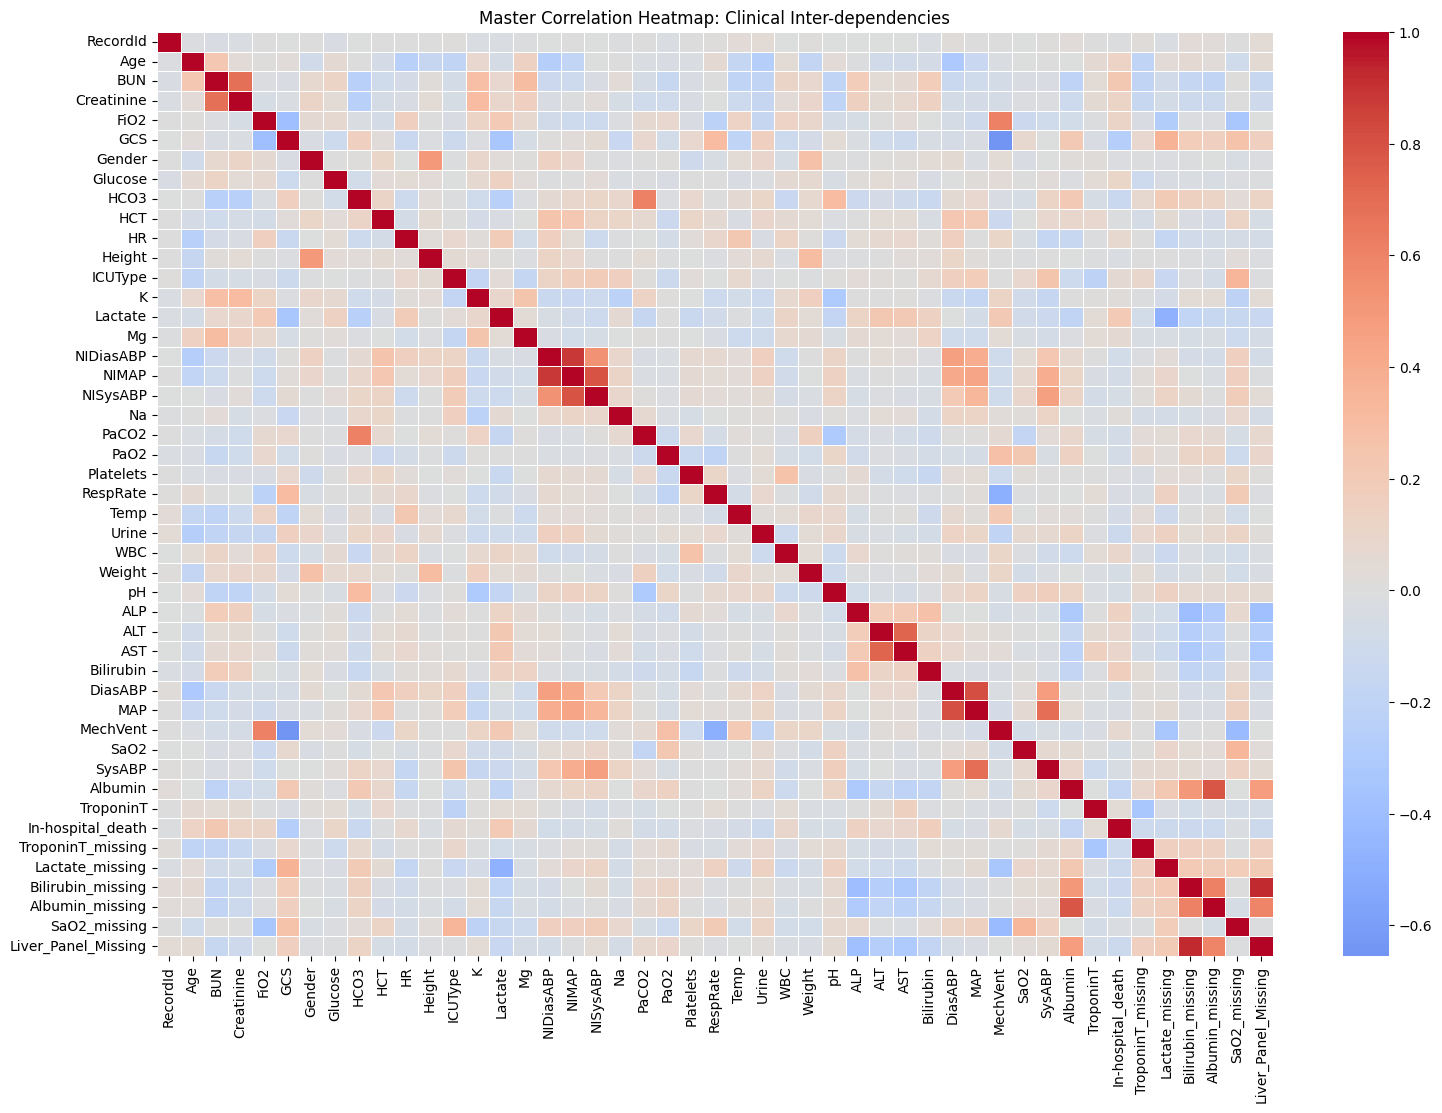

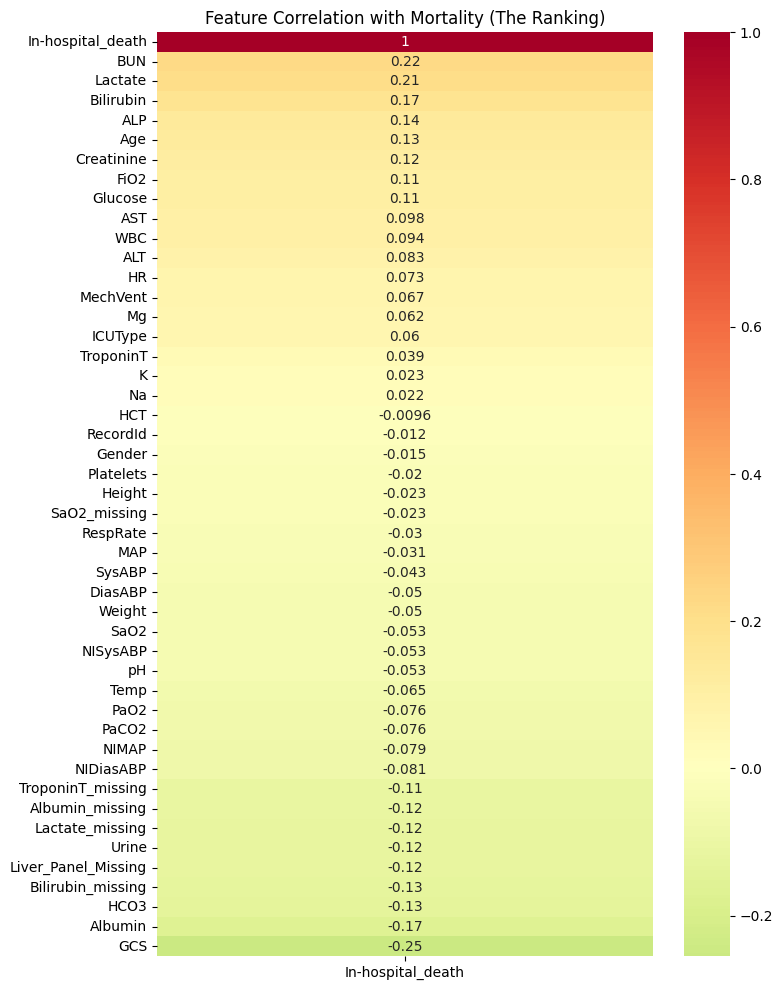

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the full correlation matrix
# We drop 'RecordID' as it's not a clinical feature
corr_matrix = df.drop(columns=['RecordID'], errors='ignore').corr()

# 2. Plotting the Giant Heatmap (The Big Picture)
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Master Correlation Heatmap: Clinical Inter-dependencies")
plt.show()

# 3. The 'Targeted' View: What correlates with Death?
death_corr = corr_matrix['In-hospital_death'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(8, 12))
sns.heatmap(death_corr, annot=True, cmap='RdYlGn_r', center=0)
plt.title("Feature Correlation with Mortality (The Ranking)")
plt.show()

In [ ]:
death_final=death_corr.abs().sort_values(by='In-hospital_death', ascending=False)
death_final

,In-hospital_death
In-hospital_death,1.000000
GCS,0.254827
BUN,0.223401
Lactate,0.207026
Bilirubin,0.172419
Albumin,0.170043
ALP,0.138506
HCO3,0.132816
Age,0.130700
Bilirubin_missing,0.130211


In [ ]:
# Assuming 'df' is your means and 'delta_x' is your deltas
final_dataset = pd.merge(df, delta_x, on='RecordId', how='inner')

print(f"New Feature Count: {final_dataset.shape[1]}")

New Feature Count: 65


In [ ]:
import numpy as np

# A tiny value to prevent division by zero errors
epsilon = 1e-9

# 1. Cardiovascular Ratios
# Shock Index: High values (> 0.9) indicate the heart is struggling to maintain pressure.
final_dataset['Shock_Index'] = final_dataset['HR'] / (final_dataset['SysABP'] + epsilon)

# Rate Pressure Product (RPP): Measures myocardial oxygen demand.
final_dataset['RPP'] = final_dataset['HR'] * final_dataset['SysABP']

# 2. Respiratory Ratios
# P/F Ratio: Primary indicator of ARDS/Lung failure.
# Note: Ensure FiO2 is in decimal format (e.g., 0.21 to 1.0) before this step.
final_dataset['PF_Ratio'] = final_dataset['PaO2'] / (final_dataset['FiO2'] + epsilon)

# 3. Renal & Metabolic Ratios
# BUN/Creatinine: High ratio (>20) suggests dehydration; low/normal suggests kidney damage.
final_dataset['BUN_Creat_Ratio'] = final_dataset['BUN'] / (final_dataset['Creatinine'] + epsilon)

# BUN/Albumin: Strong predictor of long-term mortality and nutritional status.
if 'Albumin' in final_dataset.columns:
    final_dataset['BUN_Albumin_Ratio'] = final_dataset['BUN'] / (final_dataset['Albumin'] + epsilon)

# 4. Neurological & Trend Interaction
# GCS Severity Index: Weighting the current state by its trend.
final_dataset['GCS_Trend_Severity'] = final_dataset['GCS'] * final_dataset['GCS_delta']

# 5. Global Instability Feature
# Sum of absolute deltas for the most vital signs to capture overall "physiological chaos."
vitals_for_instability = ['HR_delta', 'SysABP_delta', 'MAP_delta', 'RespRate_delta', 'Temp_delta']
final_dataset['Total_Instability_Score'] = final_dataset[vitals_for_instability].abs().sum(axis=1)

print(f"Ratios added successfully. New shape: {final_dataset.shape}")

Ratios added successfully. New shape: (4000, 72)


In [ ]:
final_dataset.isnull().sum().sort_values(ascending=False)

,0
RecordId,0
Age,0
BUN,0
Creatinine,0
FiO2,0
...,...
PF_Ratio,0
BUN_Creat_Ratio,0
BUN_Albumin_Ratio,0
GCS_Trend_Severity,0


In [ ]:
!pip install -U ydata_profiling

from ydata_profiling import ProfileReport

profile=ProfileReport(final_dataset,title="Final_report_medical",minimal=True)

output_path = "final_report.html"
profile.to_file(output_path)

from google.colab import files
files.download(output_path)


In [ ]:
# Cap ratios at the 99th percentile to remove extreme outliers (sensor glitches)
ratio_cols = ['Shock_Index', 'RPP', 'PF_Ratio', 'BUN_Creat_Ratio', 'Total_Instability_Score']

for col in ratio_cols:
    upper_limit = final_dataset[col].quantile(0.99)
    final_dataset[col] = final_dataset[col].clip(upper=upper_limit)

print("Outlier clipping complete. Data is now 'Physiologically Sane'.")


Outlier clipping complete. Data is now 'Physiologically Sane'.


In [ ]:
# Create a list of top 20 most predictive features
top_correlations = final_dataset.corr()['In-hospital_death'].abs().sort_values(ascending=False)
print(top_correlations.head(40)) # Top 40 + the target itself

In-hospital_death      1.000000
GCS                    0.254827
BUN_Albumin_Ratio      0.249389
BUN                    0.223401
Lactate                0.207026
GCS_Trend_Severity     0.190520
GCS_delta              0.190483
Bilirubin              0.172419
Albumin                0.170043
BUN_Creat_Ratio        0.147949
ALP                    0.138506
PF_Ratio               0.133056
HCO3                   0.132816
Age                    0.130700
Bilirubin_missing      0.130211
Liver_Panel_Missing    0.121304
Urine                  0.120894
Lactate_missing        0.120146
Creatinine             0.117639
Albumin_missing        0.117007
FiO2                   0.110317
TroponinT_missing      0.109923
Glucose                0.105653
FiO2_delta             0.104594
AST                    0.098430
Shock_Index            0.094599
WBC                    0.094184
ALT                    0.082883
NIDiasABP              0.080558
NIMAP                  0.079057
PaCO2                  0.076496
PaO2    

In [ ]:
# 1. Drop the ID - it's not a feature!
features_df = final_dataset.drop(columns=['RecordId'])

# 2. Drop features with almost zero variation (Constant values)
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(features_df)
features_df = features_df.loc[:, selector.get_support()]

# 3. Identify and remove highly redundant features
corr_matrix = features_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
features_final = features_df.drop(columns=to_drop)

print(f"Reduced feature count from {features_df.shape[1]} to {features_final.shape[1]}")

Reduced feature count from 70 to 67


In [ ]:
from sklearn.preprocessing import  StandardScaler
import pandas as pd

x=features_final.drop(columns='In-hospital_death')
y=features_final['In-hospital_death']

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

x_scaled=pd.DataFrame(x_scaled,columns=x.columns)



In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report

# 1. Define the Models with "Class Weights"
# We tell the models that a '1' (Death) is roughly 6x more important than a '0'
# (Adjust this based on your specific death rate)
class_weight_dict = {0: 1, 1: 6}

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, scale_pos_weight=6, learning_rate=0.05, max_depth=4),
    "SVM (Radial)": SVC(probability=True, class_weight='balanced', kernel='rbf')
}

# 2. The Experimental Pipeline
results = []

print("🚀 Starting the ICU Model Race...\n")

for name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)

    # Get Predictions (Classes and Probabilities)
    y_pred = model.predict(x_test)
    y_probs = model.predict_proba(x_test)[:, 1]

    # Calculate Metrics
    auroc = roc_auc_score(y_test, y_probs)
    auprc = average_precision_score(y_test, y_probs)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "AUROC (Overall)": round(auroc, 4),
        "AUPRC (Precision-Recall)": round(auprc, 4),
        "F1-Score": round(f1, 4)
    })
    print(f"✅ {name} processing complete.")

# 3. Display the Leaderboard
performance_df = pd.DataFrame(results).sort_values(by="AUROC (Overall)", ascending=False)
print("\n🏆 THE LEADERBOARD")
print("="*50)
print(performance_df.to_string(index=False))

🚀 Starting the ICU Model Race...

✅ Logistic Regression processing complete.
✅ Random Forest processing complete.
✅ XGBoost processing complete.
✅ SVM (Radial) processing complete.

🏆 THE LEADERBOARD
              Model  AUROC (Overall)  AUPRC (Precision-Recall)  F1-Score
      Random Forest           0.8186                    0.4033    0.0517
            XGBoost           0.8155                    0.4034    0.4506
Logistic Regression           0.7928                    0.3863    0.4323
       SVM (Radial)           0.7882                    0.3100    0.4191


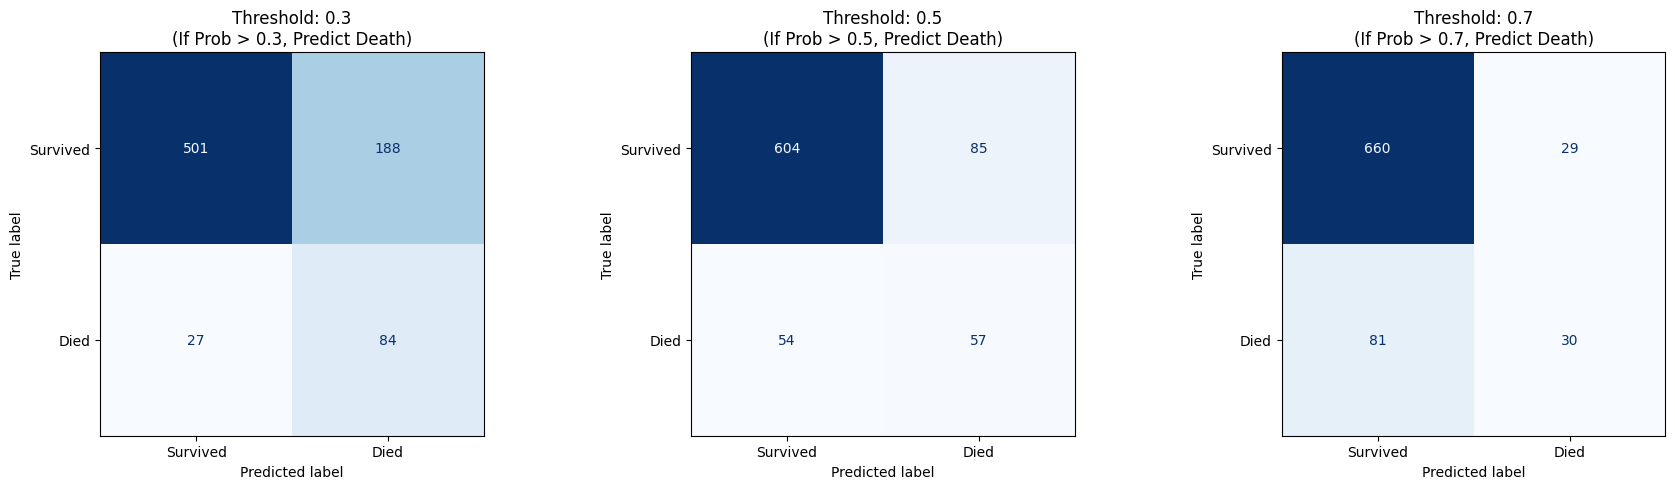

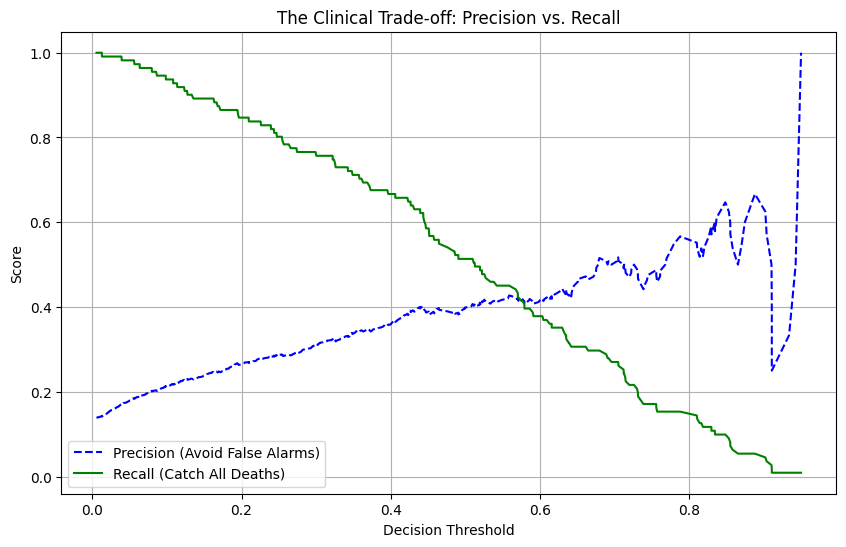

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt

# 1. Get the raw probabilities from your best model (XGBoost)
best_model = models["XGBoost"]
y_probs = best_model.predict_proba(x_test)[:, 1]

# 2. Define three different clinical "Strategies"
thresholds = [0.3, 0.5, 0.7] # Low (Aggressive), Med (Standard), High (Conservative)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, t in enumerate(thresholds):
    # Apply the threshold
    y_pred_adj = (y_probs >= t).astype(int)

    # Create the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_adj)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Died'])

    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Threshold: {t}\n(If Prob > {t}, Predict Death)")

plt.tight_layout()
plt.show()

# 3. Precision-Recall vs Threshold Plot
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], "b--", label="Precision (Avoid False Alarms)")
plt.plot(thresholds_pr, recalls[:-1], "g-", label="Recall (Catch All Deaths)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("The Clinical Trade-off: Precision vs. Recall")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [5, 6, 7] # Fine-tuning the imbalance handling
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3, # 3-fold cross-validation
    verbose=1
)

grid_search.fit(x_train, y_train)
best_xgb = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:47:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:48:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:48:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:48:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5}


In [ ]:
!pip install shap

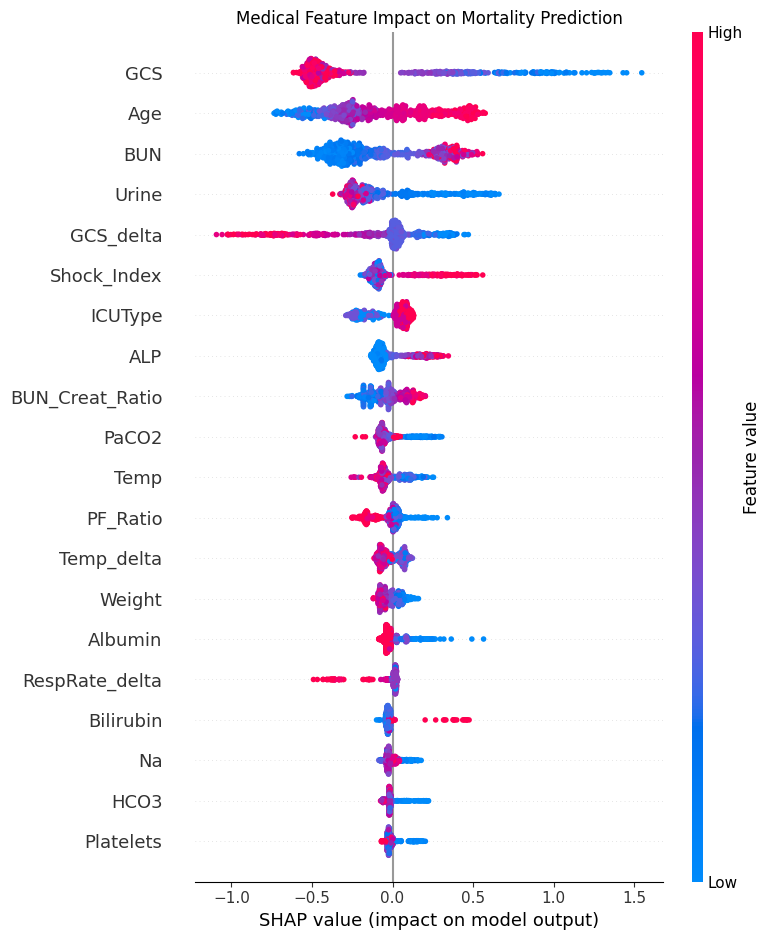

In [ ]:
import shap

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(best_xgb)

# 2. Calculate SHAP values for the test set
# This might take a minute as it calculates the contribution of every feature
shap_values = explainer.shap_values(x_test)

# 3. Create a Summary Plot (The Beeswarm Plot)
plt.title("Medical Feature Impact on Mortality Prediction")
shap.summary_plot(shap_values, x_test)